INSTALLING AND IMPORTING NECESSARY PACKAGES

In [2]:
%pip install astroquery

from astropy.io import fits
import numpy as np
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord, Galactocentric
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.coordinates import Angle
from scipy.stats import sigmaclip
hdul = fits.open('galah_dr4_allstar_240705.fits')

Note: you may need to restart the kernel to use updated packages.
The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


CHOOSING STARS \
Goal of this is to have a variety of stars to map. To do so, we will use effective temperature, metallicity and log of surface gravity to differentiate the stars. We will use GALAH to survey this.
To achieve this variety, each filter selects anywhere between n to 3n star IDs that fit that requirement. 'n' can be altered by changing n. Note that the final amount of stars selected will be 15n.

In [4]:
data = hdul[1].data

n = 100
star_IDs = []

filter1 = data[(data['fe_h'] < -1)]
sample = np.random.choice(len(filter1), 3*n, replace=False)
stargroup1 = filter1[sample]["gaiadr3_source_id"]
print("Star IDs with low metallicity - ", stargroup1 )

filter2 = data[(data['fe_h'] < 0) & (data['fe_h'] > -1)]
sample2 = np.random.choice(len(filter2), 2*n, replace=False)
stargroup2 = filter2[sample2]["gaiadr3_source_id"]
print("Star IDs with medium metallicity  - ", stargroup2 )

filter3 = data[(data['fe_h'] > np.abs(0.1))]
sample3 = np.random.choice(len(filter3), 1*n, replace=False)
stargroup3 = filter3[sample3]["gaiadr3_source_id"]
print("Star IDs with metallicity > 0.1 - ", stargroup3 )

filter4 = data[(data['teff'] > 5000)]
sample4 = np.random.choice(len(filter4), 2*n, replace=False)
stargroup4 = filter4[sample4]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 5000 - ", stargroup4 )


filter5 = data[(data['teff'] < 5000)]
sample5 = np.random.choice(len(filter5), 2*n, replace=False)
stargroup5 = filter5[sample5]["gaiadr3_source_id"]
print("Star IDs with effective temperature < 5000 - ", stargroup5 )

filter6 = data[(data['teff'] > 7000)]
sample6 = np.random.choice(len(filter6), 1*n, replace=False)
stargroup6 = filter6[sample6]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 7500 - ", stargroup6 )

filter7 = data[(data['logg'] > 4)]
sample7 = np.random.choice(len(filter7), 2*n, replace=False)
stargroup7 = filter7[sample7]["gaiadr3_source_id"]
print("Star IDs with logg > 4 (dwarfs) - ", stargroup7 )


filter8 = data[(data['logg'] < 3)]
sample8 = np.random.choice(len(filter8), 2*n, replace=False)
stargroup8 = filter8[sample8]["gaiadr3_source_id"]
print("Star IDs with logg < 3 (giants) - ", stargroup8 )



star_IDs = np.concatenate([ stargroup1, stargroup2, stargroup3, stargroup4, stargroup5, stargroup6, stargroup7,stargroup8])
print(star_IDs)

print("The number of selected stars is", len(star_IDs))

Star IDs with low metallicity -  [4155497273996100096 6190873097197851904 2344507202461348992
 4076725610962611200 6655343401895950080 4688853798927090560
 2701322605692774400 5418484599807318656 5910930019371095168
 6252945171452553984 5441975700091411456 6235516297244568704
 3636698038162820480 3606838016771693824 6371676754909607168
 4664244740121974400 6050403447306499328 6453111984838298624
 6632388416602518016 3632680113437172736 6632372508046899584
 5329584617952747776 6321692582650351232 2342903083717822848
 4047677132234038528 4071558116809728768 6086215296935866880
 5593508227972098944 4623569475678071040 6280591120017092352
 6243483221061093504 5306972096169911424 6708545780262681984
 6635363763787452928 6179994769671768320 6100892157957794560
 6450420998849951744 6685787165175154304 4295315467561970560
 4661436445686587264 5855733401809279744 4660121257978485120
 5918014683878355712 4876187013803718528 5239778393662163584
 3680167470885116928 5534549631354275840 63566195616

GAIA QUERY
\
This cell creates a query which essentially takes our star IDs and searches gaia to find RA, dec, proper motion RA, proper motion dec, parallax and radial velocity.

In [6]:
star_list = ",".join(str(i) for i in star_IDs)

query = f"""
SELECT
    source_id,
    ra, dec,
    pmra, pmdec,
    parallax, parallax_over_error,
    radial_velocity,
    ruwe
FROM gaiadr3.gaia_source
WHERE source_id IN ({star_list})
"""

job = Gaia.launch_job(query)
gaia_results = job.get_results()

CREATING SKY COORD \
This cell takes the gaia query that was just created and converts the data into a function that is now accesible. For example, to get a list of all of the RA values, we can ask for coords.ra.
\
Note the parallax and radial velocity mask. Sometimes the GAIA results will have 'faulty' parallax values which are negative. For the purpose of this project, we will ignore any negative values since we are trying to gain a random sample and are not worried about specific star clusters. Furthermore, some star IDs have radial velocities equal to 'nan'. This is not useful so we also remove these stars from the sample. To do so, we use a mask, which essentially says only only take note of these variables if the parallax is positive, otherwise ignore and also only take the variable if the radial velocity IS a number. We also apply a restriction on the GAIA variable RUWE so that only stars with values of less than 1.4 are permitted. RUWE stands for renormalised unit weight error which means how well does the star fit a single star model. Basically, we are removing any stars that could be binaries or muliple systems. We also removed parallax over error values greater than 5. This removes any stars where error is too high.\
Threshold for parallax over error.
https://www.eso.org/~hboffin/Teaching/gaia_plx-2.html#:~:text=In%20principle%2C%20if%20we%20have,changes%20the%20distribution%20of%20distance. \
Threshold for RUWE
https://www.aanda.org/articles/aa/full_html/2024/08/aa50172-24/aa50172-24.html#:~:text=With%20the%20RUWE%20being%20an,accessible%20through%20this%20RUWE%20cut.

In [8]:
parallax_rad_vel_mask = (gaia_results['parallax'] >= 0) & (~np.isnan(gaia_results['radial_velocity'])) & (gaia_results['ruwe'] < 1.4) & (gaia_results['parallax_over_error'] > 5) 


coords = SkyCoord(
    ra = gaia_results['ra'][parallax_rad_vel_mask],
    dec = gaia_results['dec'][parallax_rad_vel_mask],
    distance = (1000/gaia_results['parallax'][parallax_rad_vel_mask]) * u.pc,
    pm_ra_cosdec = gaia_results['pmra'][parallax_rad_vel_mask],
    pm_dec = gaia_results['pmdec'][parallax_rad_vel_mask],
    radial_velocity = gaia_results['radial_velocity'][parallax_rad_vel_mask]
)

print(coords)
print("The amount of star samples after removing faulty data is", len(coords.ra))

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(357.40342092,  -3.94733815,  442.07608238),
     (114.73532884,   0.44425139, 2517.2432731 ),
     ( 70.27578237,  19.14155608,  897.30828657), ...,
     (291.08059085, -22.37591221, 1080.96802251),
     (314.86861353, -38.73019445,  206.77164165),
     (321.9798043 , -23.16078007,  701.6886418 )]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(19.90421709, 10.42969065,   7.9096622),
     (-0.30634552, -5.12444273,   8.7581415),
     ( 7.24100312, -6.34777259,  25.089739 ), ...,
     ( 0.4890567 , -4.54535683, -30.882572 ),
     (71.36203652, -9.44236199, -30.496536 ),
     (10.63014552,  5.03496854,  14.305169 )]>
The amount of star samples after removing faulty data is 1123


GALACTIC COORDINATES \
Note that each of the SKY COORD variables are in celestial coordinates. Because we want to map the galaxy and look at the galaxy as a whole, galactic coordinates are more useful.

In [10]:
galactic_coords = coords.galactic
l = galactic_coords.l
b = galactic_coords.b
d = galactic_coords.distance

print(l, b, d)

[87d45m10.60037647s 218d00m31.19191301s 179d35m07.08552779s ...
 16d00m22.37954867s 3d49m32.91964673s 26d05m40.27148724s] [-62d31m05.11812874s 10d45m33.20587973s -17d39m14.49511021s ...
 -16d56m01.38486882s -40d47m25.63231913s -44d04m37.57866334s] [ 442.07608238 2517.2432731   897.30828657 ... 1080.96802251  206.77164165
  701.6886418 ] pc


PLOTTING GALACTIC COORDINATES WITH COLOUR BAR\
This is our first plot of the galaxy using galactic coordinates. We plot the position of each star by first inputting our variables and converting to radians. Note that we have wrapped the latititude at +\- 180 degrees. We then create a figure using the 'aitoff' projection which is often used for mapping galactic coordinates. We create our scatterplot and add a colourbar which is representative of the distance from the star to the Sun. The darker the colour, the closer to the centre the star is.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


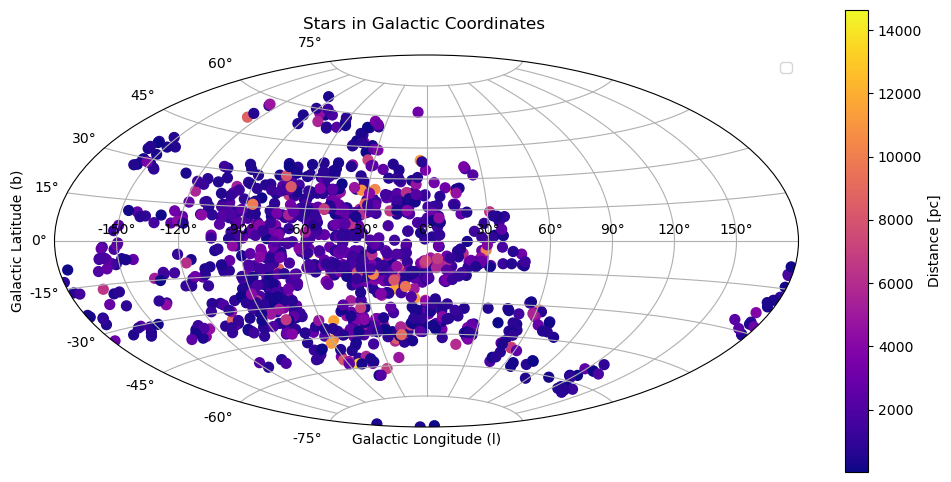

In [12]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)


sc = ax.scatter(l_rad, b_rad, c=distances, cmap='plasma', s=50)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("Distance [pc]")

ax.set_title("Stars in Galactic Coordinates \n")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffColourBar.png")
plt.show()


PLOTTING POSITION WITH VARYING SIZES \
This is a really similar idea to the prvious plot, the difference being that the size of each point is representative of the distance from the centre. The smaller the dot, the further it is.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


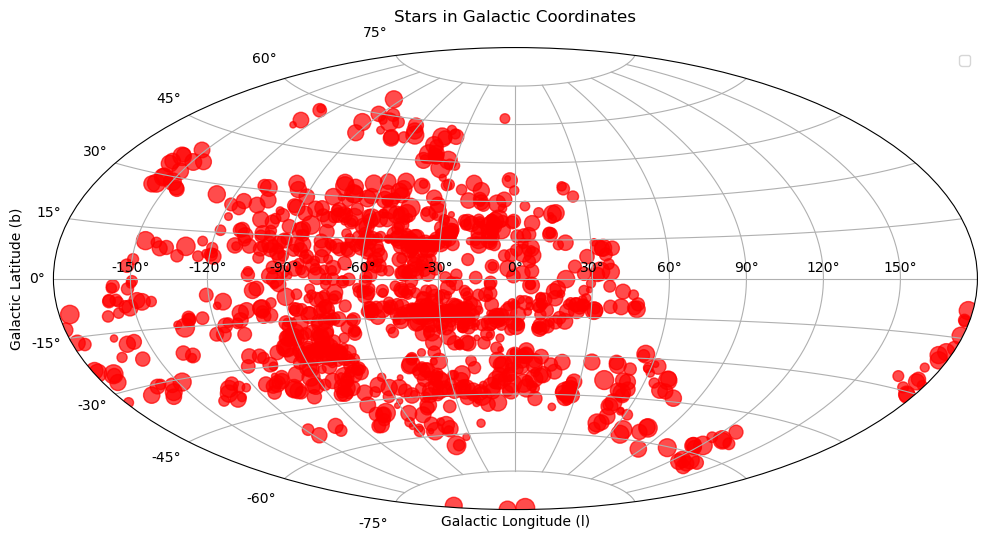

In [14]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)

size = 200 / (galactic_coords.distance.value/1000 + 1)

sc = ax.scatter(l_rad, b_rad, c='red', s=size, alpha=0.7)


ax.set_title("Stars in Galactic Coordinates\n")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffSizeVariation.png")
plt.show()

CARTESIAN COORDINATES \
This is a conversion of the coordinates into cartesian coordinates.


In [16]:
x = galactic_coords.cartesian.x.value
y = galactic_coords.cartesian.y.value
z = galactic_coords.cartesian.z.value

print(x, y, z)


[    7.99869169 -1948.51326678  -855.027271   ...   994.00957784
   156.19875537   452.71345466] [  203.8473444  -1522.81998604     6.18867029 ...   285.14438031
    10.44538796   221.72834304] [-392.19069816  469.92449954 -272.12538903 ... -314.84838768 -135.08276901
 -488.11271229]


CARTESIAN PLOT\
This is a cartesian plot for the stars. This was just another way of visualising the stars position.

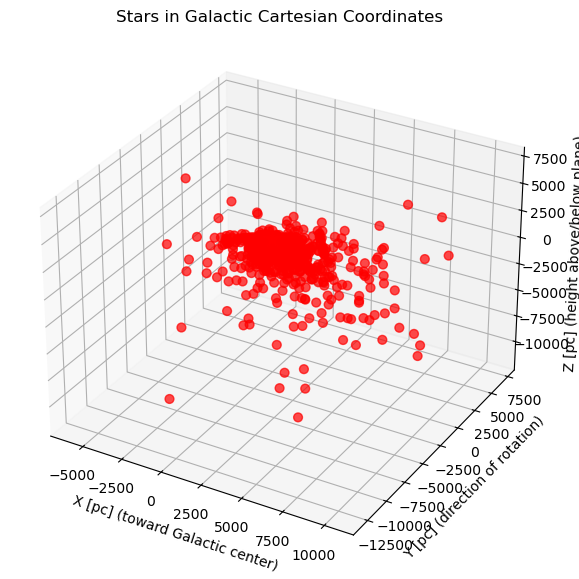

In [18]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c='red', s=40, alpha=0.7)

ax.scatter(0, 0, 0, color='orange', s=200, marker='*', label='Sun')


ax.set_xlabel('X [pc] (toward Galactic center)')
ax.set_ylabel('Y [pc] (direction of rotation)')
ax.set_zlabel('Z [pc] (height above/below plane)')
ax.set_title('Stars in Galactic Cartesian Coordinates')
plt.savefig("3D.png")
plt.show()

QUIVER PLOT \
Here we are using the proper motions to plot the stars velocity. To do so we use a quiver plot to represent magnitude and direction. Because this plot is 2D, it is difficult to determine exactly what this represents, especially in terms of direction.

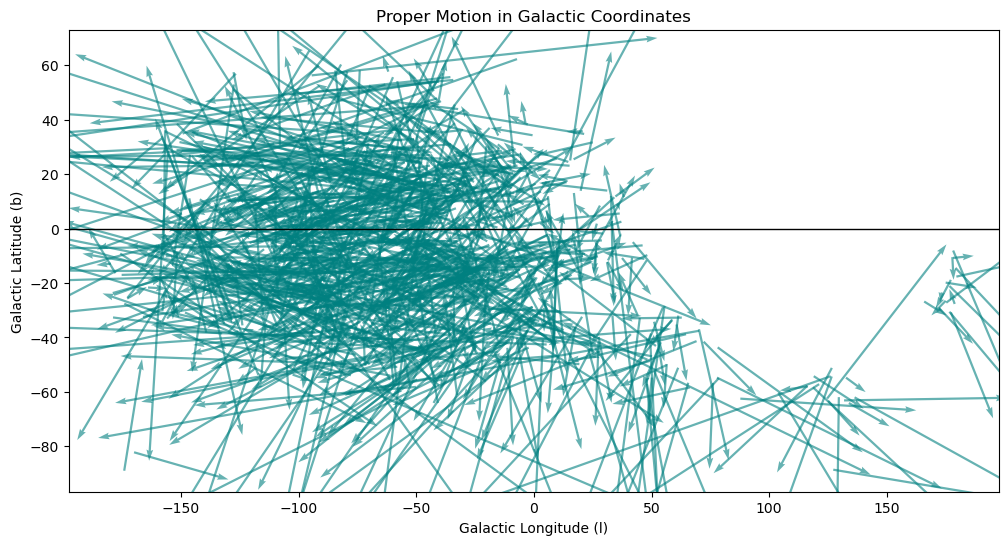

In [20]:
gal = coords.galactic

plt.figure(figsize=(12, 6))

plt.quiver(
    gal.l.wrap_at('180d').degree,
    gal.b.degree,
    gal.pm_l_cosb.value * 50,
    gal.pm_b.value * 50,
    angles='xy',
    scale_units='xy',
    scale=15,
    color='teal',
    alpha=0.6,
)

plt.axhline(0, color='black', lw=1)
plt.xlabel("Galactic Longitude (l)")
plt.ylabel("Galactic Latitude (b)")
plt.title("Proper Motion in Galactic Coordinates")
plt.savefig("Proper Motion")
plt.show()

TOP DOWN GALAXY PLOT - CARTSIAN COORDINATES\
This plot is to more so get a better look at what we are dealing with. There are two plots here, the first is a view from the top of the galaxy in cartesian with a quiver plot. The second is a slightly more zoomed in version. We convert out coordinates into galactocentric coordinates and also our x and y velocities in cartesian coordinates. These are plotted and the Sun's position in the galaxy is overlaid with the orange star. Zooming in, we see stars travelling in the same direction with a few outliers. Note that this not proper motion but rather

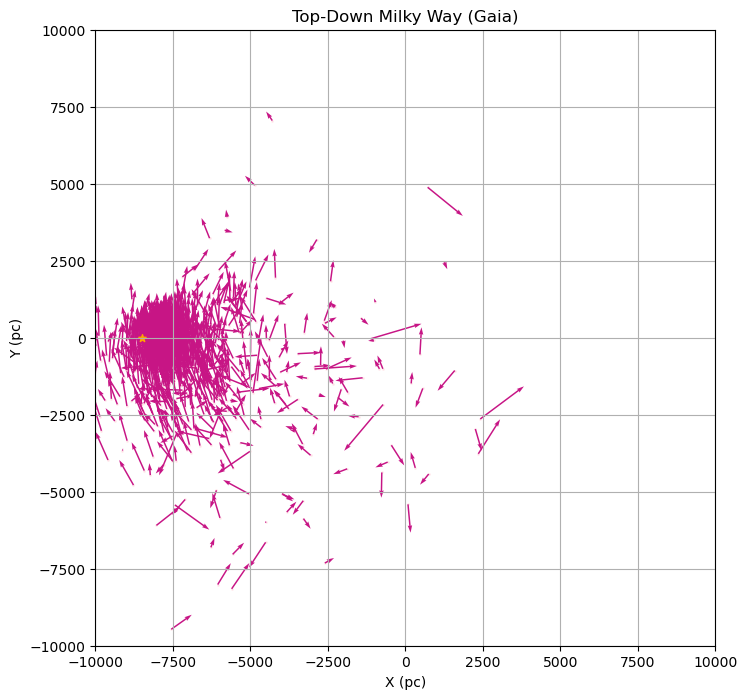

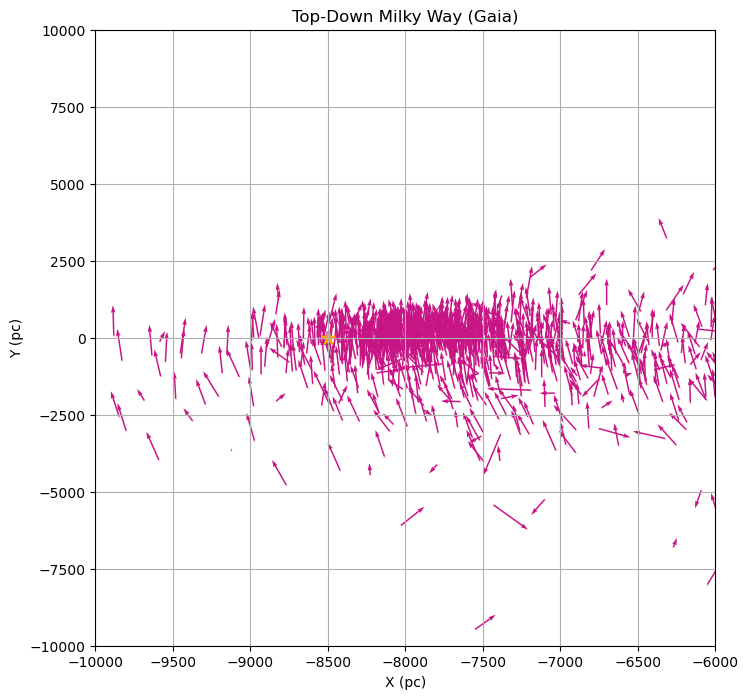

In [22]:
galcen = coords.transform_to(Galactocentric())
x = galcen.cartesian.x.value
y = galcen.cartesian.y.value

# note that v_x is
vx = galcen.v_x.value
vy = galcen.v_y.value

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=1, alpha=0.3, color = "pink")

plt.quiver(x, y, vx, vy, scale = 5000, color = "mediumvioletred")
plt.scatter(-8.5*10**3, 0, s=30, color="orange", marker='*')
plt.xlabel("X (pc)")
plt.xlim(-10000, 10000)
plt.ylim(-10000, 10000)
plt.ylabel("Y (pc)")
plt.title("Top-Down Milky Way (Gaia)")
plt.grid()
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=1, alpha=0.3, color = "pink")

plt.quiver(x, y, vx, vy, scale = 5000, color = "mediumvioletred")
plt.scatter(-8.5*10**3, 0, s=100, color="orange", marker='*')
plt.xlabel("X (pc)")
plt.xlim(-10000, -6000)
plt.ylim(-10000, 10000)
plt.ylabel("Y (pc)")
plt.title("Top-Down Milky Way (Gaia)")
plt.grid()
plt.show()

METALLICITY & ALPHA ABUNDANCE \
This block is to assign each star ID a value for metallicity and alpha abundance using Gaia. In doing so, the parallax and radial velocity mask are used so that only stars with actual data are used.

In [24]:
parallax_rad_vel_mask = (gaia_results['parallax'] >= 0) & (~np.isnan(gaia_results['radial_velocity'])) & (gaia_results['ruwe'] < 1.4) & (gaia_results['parallax_over_error'] > 5)
                                                                                                                                                                                   

feh_list = []
for star in star_IDs[parallax_rad_vel_mask]:
    mask = data['gaiadr3_source_id'] == star
    feh_list.append(data['fe_h'][mask][0])

feh_array = np.array(feh_list)
print("Number of star samples in feh is", len(feh_list))

alpha_list = []
for star in star_IDs[parallax_rad_vel_mask]:
    mask = data['gaiadr3_source_id'] == star
    alpha_list.append(((data['mg_fe'] + data['si_fe'] + data["ca_fe"]) / 3.0)[mask][0])
    
alpha_array = np.array(alpha_list)
print("Number of star samples in alpha is", len(alpha_list))


Number of star samples in feh is 1123
Number of star samples in alpha is 1123


COLOUR MAPPING FOR METALLICITY AND ALPHA ABUNDANCES \
Similar to the galactic coordinate map from above, this time colour indicates the metallicity and alpha abundances of each star. Our sun has a metallicity of 0, which lies around the lighter green. Note that this is a galactic projection and so this as observed from the sun.

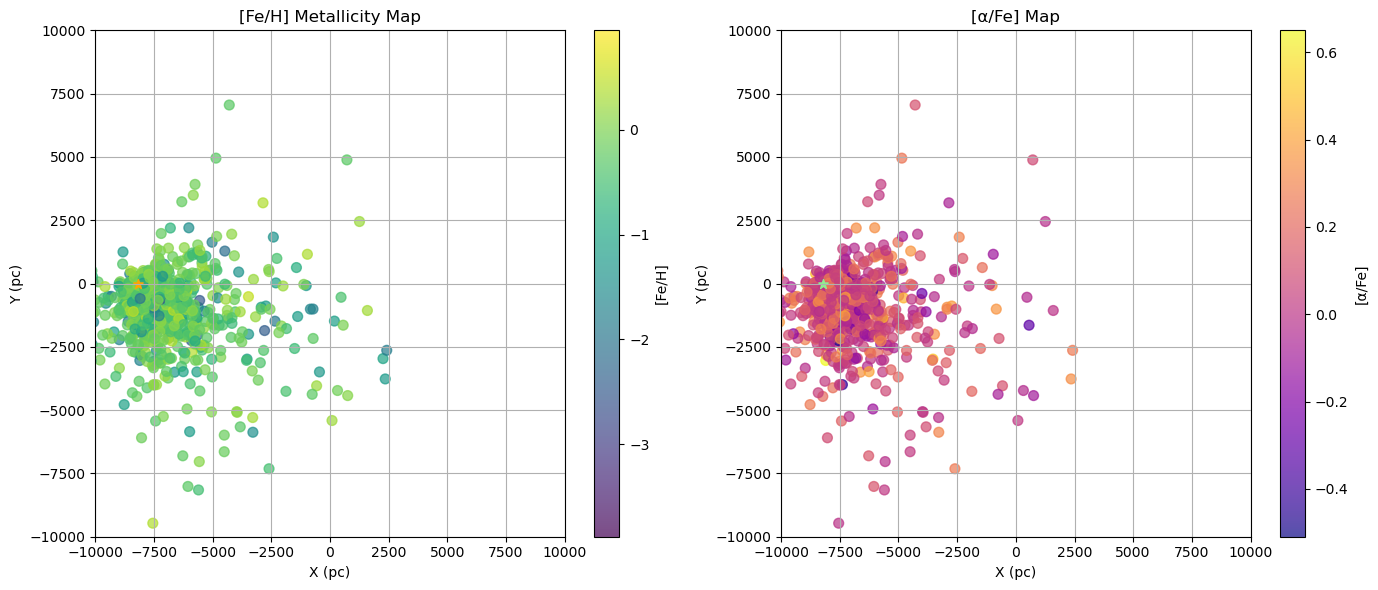

In [26]:
galcen = coords.transform_to(Galactocentric())
x = galcen.cartesian.x.value
y = galcen.cartesian.y.value

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

sc1 = axes[0].scatter(x, y, c=feh_array, s=50, alpha=0.7, cmap='viridis')
axes[0].scatter(-8.2*10**3, 0, s=50, color="orange", marker='*')
axes[0].set_xlabel("X (pc)")
axes[0].set_ylabel("Y (pc)")
axes[0].set_xlim(-10000, 10000)
axes[0].set_ylim(-10000, 10000)
axes[0].set_title("[Fe/H] Metallicity Map")
axes[0].grid()

cbar1 = fig.colorbar(sc1, ax=axes[0])
cbar1.set_label('[Fe/H]')

sc2 = axes[1].scatter(x, y, c=alpha_array, s=50, alpha=0.7, cmap='plasma')
axes[1].scatter(-8.2*10**3, 0, s=50, color="lightgreen", marker='*')
axes[1].set_xlabel("X (pc)")
axes[1].set_ylabel("Y (pc)")
axes[1].set_xlim(-10000, 10000)
axes[1].set_ylim(-10000, 10000)
axes[1].set_title("[α/Fe] Map")
axes[1].grid()

cbar2 = fig.colorbar(sc2, ax=axes[1])
cbar2.set_label('[α/Fe]')

plt.tight_layout()
plt.show()

GALACTIC COORDINATES WITH METALICITY AND ALPHA ABUNDANCES\
This is a plot of galactic coordinates with metallicity and alpha abundace colour mapping.

/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


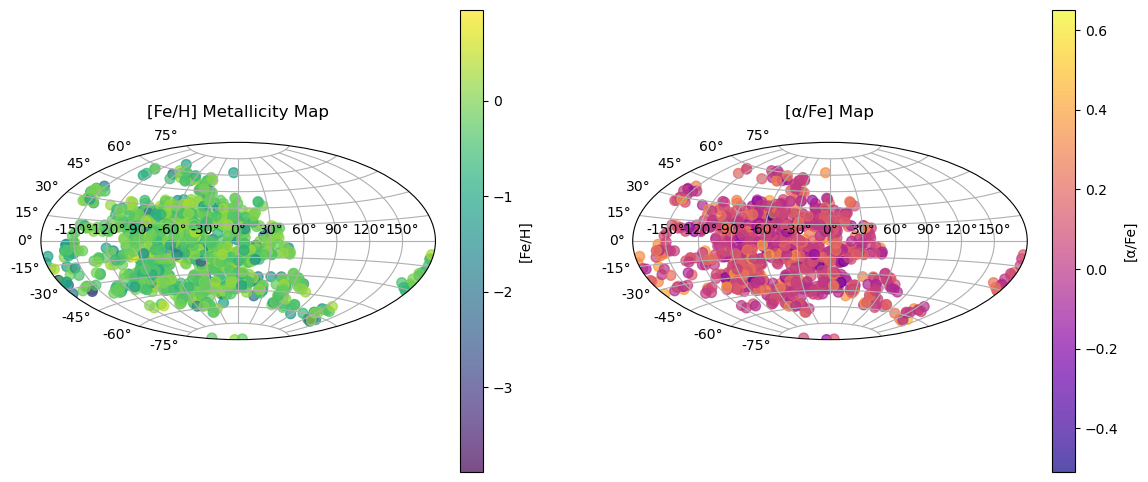

In [28]:
gal = coords.galactic
l_rad = gal.l.wrap_at(180*u.deg).radian
b_rad = gal.b.radian

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='aitoff')
sc1 = ax1.scatter(l_rad, b_rad, c=feh_array, s=50, alpha=0.7, cmap='viridis')
ax1.set_title("[Fe/H] Metallicity Map\n")
ax1.grid(True)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('[Fe/H]')

ax2 = fig.add_subplot(1, 2, 2, projection='aitoff')
sc2 = ax2.scatter(l_rad, b_rad, c=alpha_array, s=50, alpha=0.7, cmap='plasma')
ax2.set_title("[α/Fe] Map\n")
ax2.grid(True)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('[α/Fe]')

CARTESIAN COORDINATES SIDE VIEW OF GALAXY WITH METALLICITY AND ALPHA ABUNDANCE COLOUR MAPPING \
Using galactocentric coordinates with colour mapping, note the spread of stars. A few low metallicity stars falling to the outerskirt regions of the galaxy as expected.

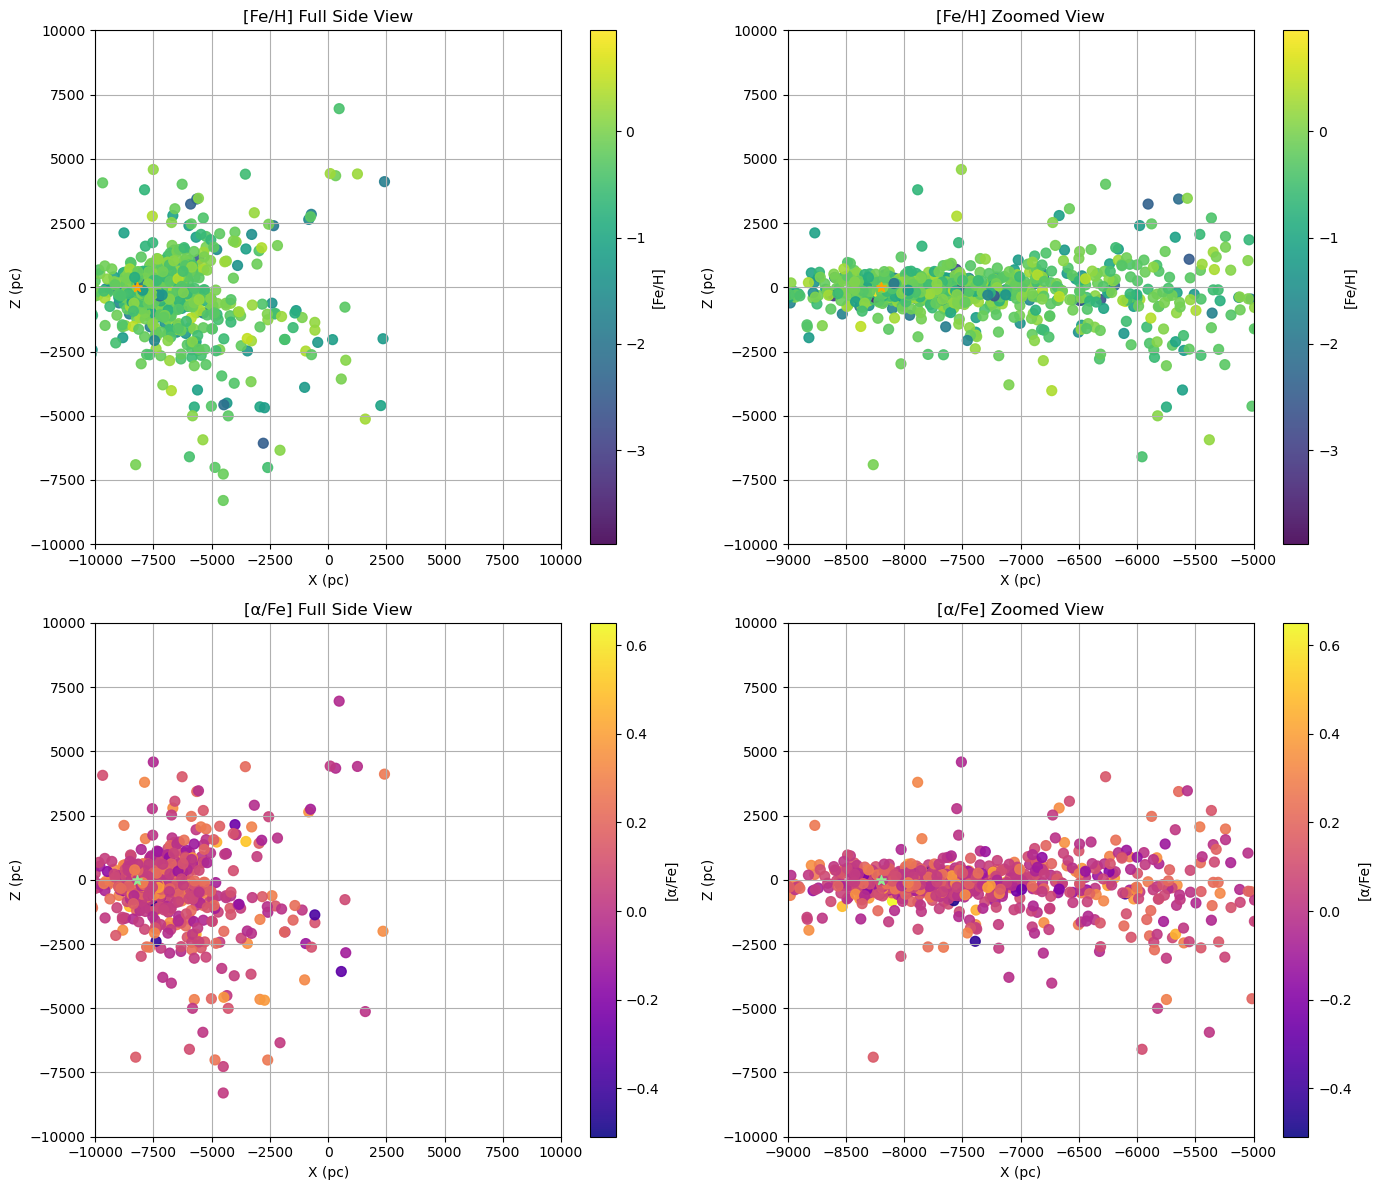

In [30]:
galcen = coords.transform_to(Galactocentric())
x = galcen.cartesian.x.value
z = galcen.cartesian.z.value

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sc1 = axes[0, 0].scatter(x, z, c=feh_array, s=50, alpha=0.9, cmap='viridis')
axes[0, 0].scatter(-8.2*10**3, 0, s=50, color="orange", marker='*')
axes[0, 0].set_xlim(-10000, 10000)
axes[0, 0].set_ylim(-10000, 10000)
axes[0, 0].set_xlabel("X (pc)")
axes[0, 0].set_ylabel("Z (pc)")
axes[0, 0].set_title("[Fe/H] Full Side View")
axes[0, 0].grid()

cbar1 = fig.colorbar(sc1, ax=axes[0, 0])
cbar1.set_label('[Fe/H]')

sc2 = axes[0, 1].scatter(x, z, c=feh_array, s=50, alpha=0.9, cmap='viridis')
axes[0, 1].scatter(-8.2*10**3, 0, s=50, color="orange", marker='*')
axes[0, 1].set_xlim(-9000, -5000)
axes[0, 1].set_ylim(-10000, 10000)
axes[0, 1].set_xlabel("X (pc)")
axes[0, 1].set_ylabel("Z (pc)")
axes[0, 1].set_title("[Fe/H] Zoomed View")
axes[0, 1].grid()

cbar2 = fig.colorbar(sc2, ax=axes[0, 1])
cbar2.set_label('[Fe/H]')


sc3 = axes[1, 0].scatter(x, z, c=alpha_array, s=50, alpha=0.9, cmap='plasma')
axes[1, 0].scatter(-8.2*10**3, 0, s=50, color="lightgreen", marker='*')
axes[1, 0].set_xlim(-10000, 10000)
axes[1, 0].set_ylim(-10000, 10000)
axes[1, 0].set_xlabel("X (pc)")
axes[1, 0].set_ylabel("Z (pc)")
axes[1, 0].set_title("[α/Fe] Full Side View")
axes[1, 0].grid()

cbar3 = fig.colorbar(sc3, ax=axes[1, 0])
cbar3.set_label('[α/Fe]')

sc4 = axes[1, 1].scatter(x, z, c=alpha_array, s=50, alpha=0.9, cmap='plasma')
axes[1, 1].scatter(-8.2*10**3, 0, s=50, color="lightgreen", marker='*')
axes[1, 1].set_xlim(-9000, -5000)
axes[1, 1].set_ylim(-10000, 10000)
axes[1, 1].set_xlabel("X (pc)")
axes[1, 1].set_ylabel("Z (pc)")
axes[1, 1].set_title("[α/Fe] Zoomed View")
axes[1, 1].grid()

cbar4 = fig.colorbar(sc4, ax=axes[1, 1])
cbar4.set_label('[α/Fe]')


plt.tight_layout()
plt.show()

GALACTIC CARTESIAN COORDINATES 3D PLOT \
More so a sanity check for how our stars are sitting.

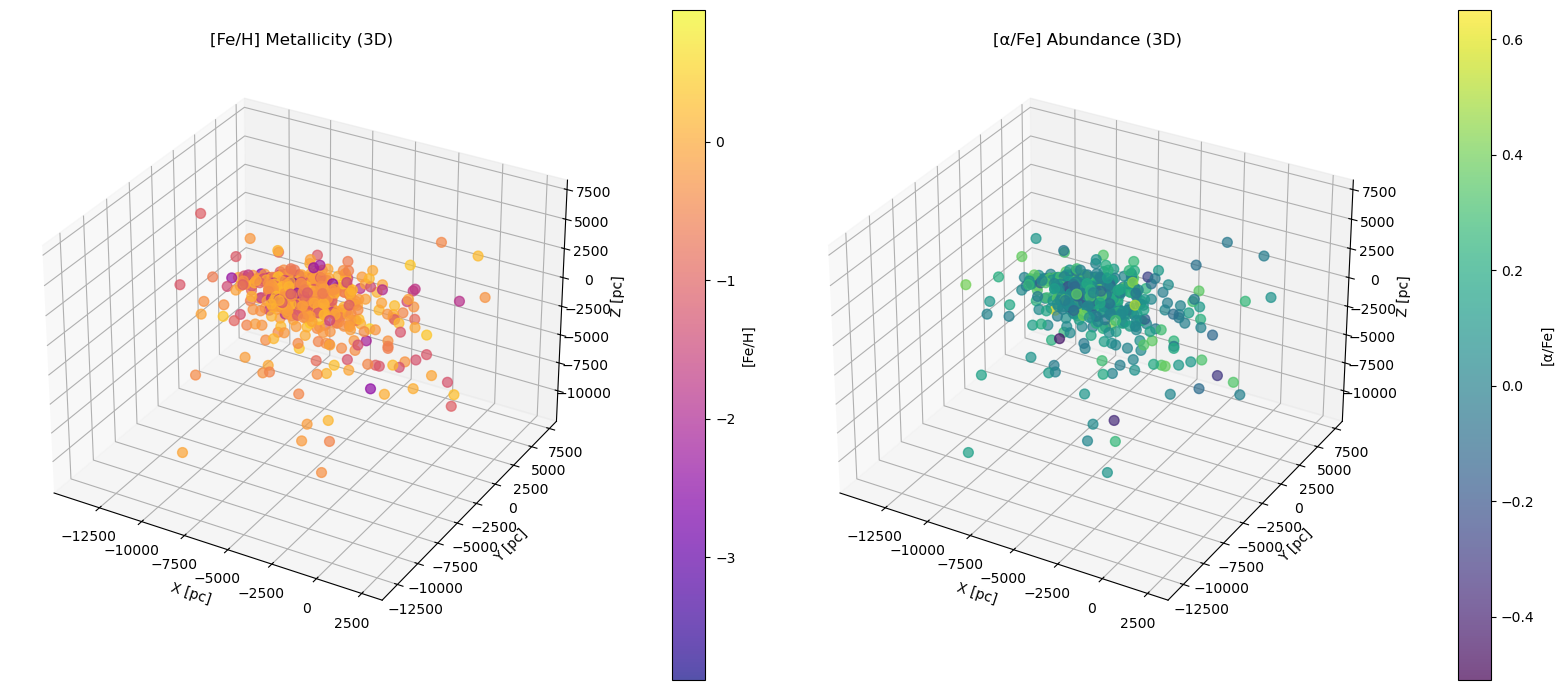

In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 7))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(x, y, z, alpha=0.7, c=feh_array, s=50, cmap='plasma')
cbar1 = plt.colorbar(sc1, ax=ax1, pad=0.1)
cbar1.set_label('[Fe/H]')
ax1.set_xlabel('X [pc]')
ax1.set_ylabel('Y [pc]')
ax1.set_zlabel('Z [pc]')
ax1.set_title('[Fe/H] Metallicity (3D)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(x, y, z, alpha=0.7, c=alpha_array, s=50, cmap='viridis')
cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.1)
cbar2.set_label('[α/Fe]')
ax2.set_xlabel('X [pc]')
ax2.set_ylabel('Y [pc]')
ax2.set_zlabel('Z [pc]')
ax2.set_title('[α/Fe] Abundance (3D)')

plt.tight_layout()
plt.savefig("3D_dual.png")
plt.show()

THEORIES FOR METALICITY AND DISTANCE \
From this caltech website, we have that halo stars have metallicity less than -1, bulge metallicity occurs around -0.2 and thin disk metallicity at -0.6 \
for height restriction - https://www.aanda.org/articles/aa/full_html/2014/07/aa22944-13/aa22944-13.html#:~:text=2000;%20Fuhrmann%202004;%20Bensby%20et,2012c \
for thin-disk - https://ned.ipac.caltech.edu/level5/Sept08/Matteucci/Matteucci3.html \
alpha abundace cuts - https://arxiv.org/abs/1908.03370 and https://en.wikipedia.org/wiki/%28%CE%B1/Fe%29_versus_%28Fe/H%29_diagram


In [34]:
halo_mask = (feh_array < -1) & (alpha_array <= 0.4) & (alpha_array >= 0.2)
thin_disk_mask = (feh_array >= -0.8) & (feh_array <= 0.2) & (alpha_array <= 0.1) & (np.abs(galcen.z) < 0.3 * u.kpc)
bulge_mask = (feh_array > -0.4)

CALCULATING VELOCITIES \
This is the velocity in cartesian coordinates. V is the velocity in the direction of galactic rotation. V_phi is azimuthal velocity.

In [36]:
galcen = coords.transform_to(Galactocentric())
U = galcen.v_x.to(u.km/u.s).value
V = galcen.v_y.to(u.km/u.s).value
W = galcen.v_z.to(u.km/u.s).value

gal_cyl = galcen.represent_as('cylindrical')
v_rho = gal_cyl.differentials['s'].d_rho.to(u.km/u.s)
v_phi = (gal_cyl.rho * gal_cyl.differentials['s'].d_phi).to(u.km/u.s, u.dimensionless_angles())
v_z = gal_cyl.differentials['s'].d_z.to(u.km/u.s)

HISTOGRAM OF TANGENTIAL VELOCITY VS NUMBER OF STARS \
Seperating by metallicity as stated in "THERORIES FOR METALLICITY AND DISTANCE" we have a histogram. The focus here is on thin disk, these are the most stable stars and will give the overall rotational velocity of the Milky Way. We notice for the thin disk histogram (green) has less spread with velocities.

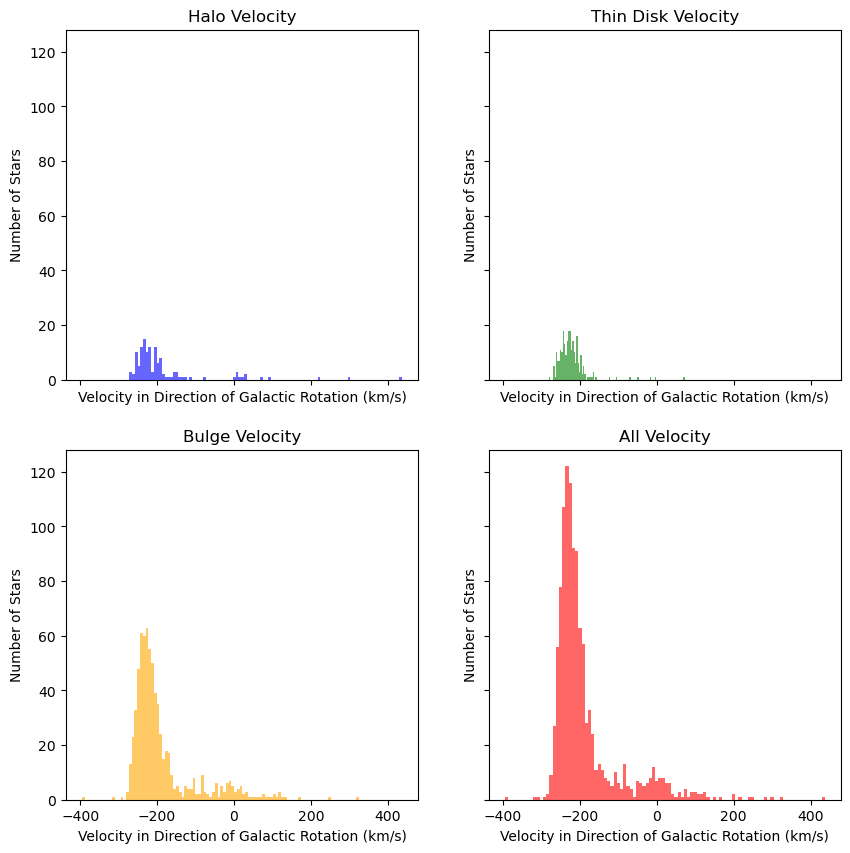

In [38]:
bins = 100
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize = (10,10))

axs[0, 0].hist(v_phi[halo_mask], bins=bins, alpha=0.6, color='blue', label='Halo ([Fe/H]<-1)')
axs[0, 0].set_title('Halo Velocity')

axs[0, 1].hist(v_phi[thin_disk_mask], bins=bins, alpha=0.6, color='green', label='Thin Disk (-0.8<[Fe/H]<-0.4)')
axs[0, 1].set_title('Thin Disk Velocity')

axs[1, 0].hist(v_phi[bulge_mask], bins=bins, alpha=0.6, color='orange', label='Bulge (-0.4<[Fe/H])')
axs[1, 0].set_title('Bulge Velocity')

axs[1, 1].hist(v_phi, bins=bins, alpha=0.6, color='red', label='Bulge (-0.4<[Fe/H])')
axs[1, 1].set_title('All Velocity')


for ax in axs.flat:
    ax.set(xlabel='Velocity in Direction of Galactic Rotation (km/s)', ylabel='Number of Stars')



RADIUS VS VELOCITY \
Plotting only the thin disk stars against velocity. We expect to see all velocities slightly above 200 here.

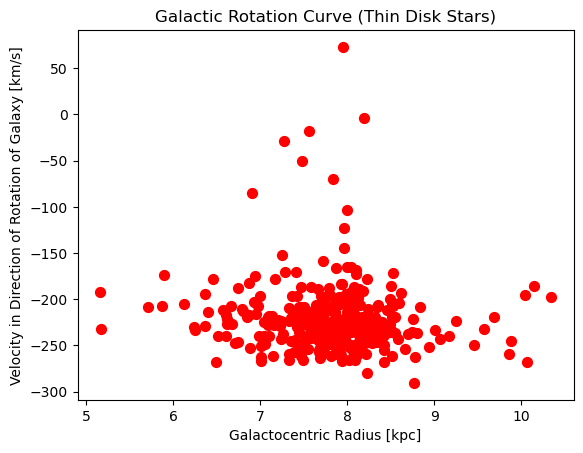

In [40]:
R = np.sqrt(galcen.x.value**2 + galcen.y.value**2 + galcen.z.value**2)

mask10 = (feh_array >= -0.8) & (feh_array <= 0.2) & (alpha_array <= 0.1) & (np.abs(galcen.z) < 0.5 * u.kpc)
V_disk = v_phi[mask10]
R_disk = R[mask10]

plt.scatter(R_disk/1000, V_disk, c='red', s=50)
plt.xlabel("Galactocentric Radius [kpc]")
plt.ylabel("Velocity in Direction of Rotation of Galaxy [km/s]")
plt.title("Galactic Rotation Curve (Thin Disk Stars)")
plt.show()

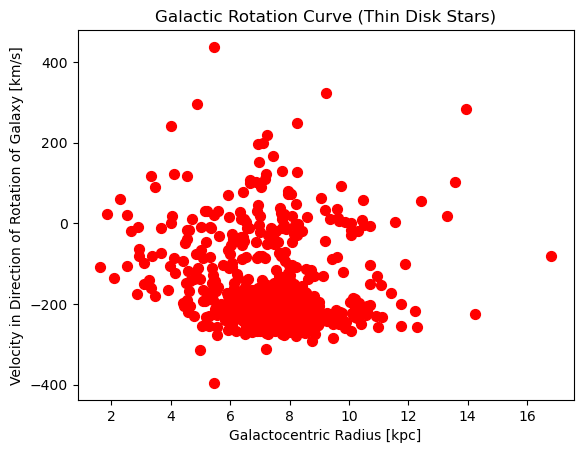

In [41]:
R = np.sqrt(galcen.x.value**2 + galcen.y.value**2 + galcen.z.value**2)

V_disk = v_phi
R_disk = R

plt.scatter(R_disk/1000, V_disk, c='red', s=50)
plt.xlabel("Galactocentric Radius [kpc]")
plt.ylabel("Velocity in Direction of Rotation of Galaxy [km/s]")
plt.title("Galactic Rotation Curve (Thin Disk Stars)")
plt.show()

CALCULATING MEAN OF DATA WITH STD DEV \
The second cell doesn't remove any outliers whereas the third does. We get a more precise answer and also better accuracy. 


In [43]:
V_disk_all = V[mask10]

V_disk = V_disk_all[~np.isnan(V_disk_all)]


In [44]:
mean_rotation = np.mean(V_disk)
std_rotation = np.std(V_disk)
N = len(V_disk)
std_error = std_rotation / np.sqrt(N)

print(f"Rotation velocity: {mean_rotation} ± {std_error} km/s")
print("Number of stars:", N)

Rotation velocity: 219.01677118332032 ± 2.1789555594518175 km/s
Number of stars: 334


In [45]:
filtered_data, low_limit, high_limit = sigmaclip(V_disk, low=2.0, high=2.0)

mean_rotation = np.mean(filtered_data)
std_rotation = np.std(filtered_data)
N = len(filtered_data)
std_error = std_rotation / np.sqrt(N)

print(f"Rotation velocity: {mean_rotation} ± {std_error} km/s")
print("Number of stars:", N)

Rotation velocity: 229.38439547780868 ± 1.0712525031241118 km/s
Number of stars: 282
